In [19]:
import pandas as pd
import numpy as np
import networkx as nx
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
import shap
import json
import time
import ast
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from scipy.spatial import cKDTree
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

class PrecisionNumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        return super(PrecisionNumpyEncoder, self).default(obj)

comprehensive_results_dictionary = {}
comprehensive_results_dictionary['metadata'] = {
    'experiment_name': 'Spatio-Temporal KD-Tree Graph-Enhanced Demand Forecasting with 5-Fold Cross Validation',
    'environment': 'CPU-Optimized',
    'date_executed': time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
    'datasets_used': ['Accommodation - Transactions by HotelCode.xlsx', 'accommodations.csv', 'activity.csv']
}

start_time_global = time.time()

# 1. LOAD AND AGGREGATE DEMAND
transactions_df = pd.read_excel('Accommodation - Transactions by HotelCode.xlsx')
transactions_aggregated = transactions_df.groupby('Property Id')['Number Transactions'].sum().reset_index()
transactions_aggregated.rename(columns={'Property Id': 'id', 'Number Transactions': 'total_demand'}, inplace=True)

# 2. LOAD FEATURES
acc_usecols = ['id', 'popularity_score', 'star_rating', 'guest_rating', 'availability_score', 'price_in_aud', 'destination_coordinate', 'providers']
accommodations_df = pd.read_csv('accommodations.csv', usecols=acc_usecols)

act_usecols = ['product_id', 'normalized_rating', 'price_in_aud', 'duration_hours', 'destination_coordinate', 'categories_as_string']
activities_df = pd.read_csv('activity.csv', usecols=act_usecols)

comprehensive_results_dictionary['dataset_statistics'] = {
    'raw_transactions_records': len(transactions_df),
    'unique_properties_in_transactions': len(transactions_aggregated),
    'total_accommodations_loaded': len(accommodations_df),
    'total_activities_loaded': len(activities_df)
}

merged_df = pd.merge(accommodations_df, transactions_aggregated, on='id', how='inner')
merged_df['total_demand'] = merged_df['total_demand'].fillna(0)
comprehensive_results_dictionary['dataset_statistics']['merged_properties_with_demand'] = len(merged_df)

# 3. SPATIAL PREPROCESSING
def parse_coordinates(coord_str):
    if pd.isna(coord_str):
        return 0.0, 0.0
    try:
        parts = str(coord_str).split(',')
        if len(parts) == 2:
            return float(parts[0].strip()), float(parts[1].strip())
    except: pass
    try:
        coord_dict = ast.literal_eval(str(coord_str))
        if isinstance(coord_dict, dict):
            return float(coord_dict.get('lat', 0.0)), float(coord_dict.get('lon', 0.0))
    except: pass
    return 0.0, 0.0

merged_df['lat'], merged_df['lon'] = zip(*merged_df['destination_coordinate'].apply(parse_coordinates))
activities_df['lat'], activities_df['lon'] = zip(*activities_df['destination_coordinate'].apply(parse_coordinates))

merged_df = merged_df[(merged_df['lat'] != 0.0) & (merged_df['lon'] != 0.0)].reset_index(drop=True)
activities_df = activities_df[(activities_df['lat'] != 0.0) & (activities_df['lon'] != 0.0)].reset_index(drop=True)

# 4. SPATIAL GRAPH CONSTRUCTION (KD-TREE)
prop_coords = merged_df[['lat', 'lon']].values
act_coords = activities_df[['lat', 'lon']].values
tree = cKDTree(act_coords)
k_neighbors = 30
distances, indices = tree.query(prop_coords, k=k_neighbors)

spatial_graph = nx.Graph()
edge_list = []

for i, prop_idx in enumerate(merged_df.index):
    prop_id = f"P_{merged_df.loc[prop_idx, 'id']}"
    for j in range(k_neighbors):
        act_idx = indices[i, j]
        act_id = f"A_{activities_df.loc[act_idx, 'product_id']}"
        dist = distances[i, j]
        weight = 1.0 / (dist + 1e-4)
        edge_list.append((prop_id, act_id, {'weight': weight}))

spatial_graph.add_edges_from(edge_list)

comprehensive_results_dictionary['graph_topology'] = {
    'total_nodes': spatial_graph.number_of_nodes(),
    'total_edges': spatial_graph.number_of_edges(),
    'density': nx.density(spatial_graph)
}

# 5. MACRO-TOPOLOGY FLOW MATRIX EXTRACTION (For Chord Diagram)
provider_flow = {}
prop_providers = dict(zip(merged_df['id'].apply(lambda x: f"P_{x}"), merged_df['providers'].fillna('Unknown')))
act_categories = dict(zip(activities_df['product_id'].apply(lambda x: f"A_{x}"), activities_df['categories_as_string'].fillna('General')))

for edge in spatial_graph.edges():
    u, v = edge
    if u.startswith('P_') and v.startswith('A_'):
        prov = str(prop_providers.get(u, 'Unknown')).split(',')[0].strip()
        cat = str(act_categories.get(v, 'General')).split(',')[0].strip()
    elif v.startswith('P_') and u.startswith('A_'):
        prov = str(prop_providers.get(v, 'Unknown')).split(',')[0].strip()
        cat = str(act_categories.get(u, 'General')).split(',')[0].strip()
    else:
        continue
    
    if prov not in provider_flow:
        provider_flow[prov] = {}
    if cat not in provider_flow[prov]:
        provider_flow[prov][cat] = 0
    provider_flow[prov][cat] += 1

top_n_prov = 5
top_n_cat = 5
prov_totals = {p: sum(provider_flow[p].values()) for p in provider_flow}
top_provs = sorted(prov_totals, key=prov_totals.get, reverse=True)[:top_n_prov]

cat_totals = {}
for p in top_provs:
    for c, count in provider_flow[p].items():
        cat_totals[c] = cat_totals.get(c, 0) + count
top_cats = sorted(cat_totals, key=cat_totals.get, reverse=True)[:top_n_cat]

filtered_flow = {}
for p in top_provs:
    filtered_flow[p] = {}
    for c in top_cats:
        filtered_flow[p][c] = provider_flow[p].get(c, 0)

comprehensive_results_dictionary['graph_topology']['macro_flow_matrix'] = filtered_flow

# 6. GRAPH FEATURE EXTRACTION
start_time_pagerank = time.time()
pagerank_scores = nx.pagerank(spatial_graph, alpha=0.85, weight='weight')
time_pagerank = time.time() - start_time_pagerank

start_time_degree = time.time()
degree_centrality = nx.degree_centrality(spatial_graph)
time_degree = time.time() - start_time_degree

comprehensive_results_dictionary['computational_efficiency'] = {
    'pagerank_seconds': time_pagerank,
    'degree_centrality_seconds': time_degree
}

graph_features = []
for pid in merged_df['id'].unique():
    node_name = f"P_{pid}"
    features = {
        'id': pid,
        'pagerank': pagerank_scores.get(node_name, 0.0),
        'degree_centrality': degree_centrality.get(node_name, 0.0)
    }
    graph_features.append(features)

graph_features_df = pd.DataFrame(graph_features)
enriched_dataset = pd.merge(merged_df, graph_features_df, on='id', how='inner')
enriched_dataset.fillna(0, inplace=True)

# 7. FEATURE ENGINEERING & SCALING
le_provider = LabelEncoder()
enriched_dataset['provider_encoded'] = le_provider.fit_transform(enriched_dataset['providers'].astype(str))

numerical_features = ['popularity_score', 'star_rating', 'guest_rating', 'availability_score', 'price_in_aud', 'pagerank', 'degree_centrality']
categorical_features = ['provider_encoded']
all_features = numerical_features + categorical_features
baseline_features = ['popularity_score', 'star_rating', 'guest_rating', 'availability_score', 'price_in_aud', 'provider_encoded']

# REMOVED StandardScaler: Tree-based models (LGBM, XGB, RF) are strictly scale-invariant.
# Removing global scaling guarantees 100% Zero Data Leakage across the 5-Fold CV.


X_proposed = enriched_dataset[all_features].values
X_baseline = enriched_dataset[baseline_features].values
y = enriched_dataset['total_demand'].values

# 8. 5-FOLD CROSS VALIDATION EXPERIMENT MATRIX
comprehensive_results_dictionary['model_evaluation'] = {}
for model_key in ['LightGBM_Proposed_Graph', 'LightGBM_Baseline', 'XGBoost_Proposed_Graph', 'XGBoost_Baseline', 'RandomForest_Proposed_Graph', 'RandomForest_Baseline']:
    comprehensive_results_dictionary['model_evaluation'][model_key] = {
        'rmse_folds': [], 'mae_folds': [], 'r2_score_folds': [], 'training_time_seconds_folds': []
    }

kf = KFold(n_splits=5, shuffle=True, random_state=42)

lgb_params = {'objective': 'regression', 'metric': 'rmse', 'boosting_type': 'gbdt', 'num_leaves': 31, 'learning_rate': 0.03, 'feature_fraction': 0.7, 'bagging_fraction': 0.8, 'bagging_freq': 5, 'verbose': -1, 'device_type': 'cpu', 'num_threads': 4}
xgb_params = {'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'max_depth': 5, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.7, 'n_jobs': 4, 'random_state': 42}
rf_params = {'n_estimators': 200, 'max_depth': 10, 'max_features': 0.7, 'n_jobs': 4, 'random_state': 42}

shap_values_list = []
X_test_shap_list = []

y_oof_true = np.zeros(len(y))
y_oof_preds = {
    'LightGBM_Proposed_Graph': np.zeros(len(y)), 'LightGBM_Baseline': np.zeros(len(y)),
    'XGBoost_Proposed_Graph': np.zeros(len(y)), 'XGBoost_Baseline': np.zeros(len(y)),
    'RandomForest_Proposed_Graph': np.zeros(len(y)), 'RandomForest_Baseline': np.zeros(len(y))
}

for train_index, test_index in kf.split(X_proposed):
    X_tr_prop, X_te_prop = X_proposed[train_index], X_proposed[test_index]
    X_tr_base, X_te_base = X_baseline[train_index], X_baseline[test_index]
    y_tr, y_te = y[train_index], y[test_index]
    y_oof_true[test_index] = y_te
    
    # LightGBM Proposed
    gbm_prop = lgb.train(lgb_params, lgb.Dataset(X_tr_prop, y_tr), num_boost_round=400)
    y_pred_lgbm_prop = gbm_prop.predict(X_te_prop)
    y_oof_preds['LightGBM_Proposed_Graph'][test_index] = y_pred_lgbm_prop
    comprehensive_results_dictionary['model_evaluation']['LightGBM_Proposed_Graph']['rmse_folds'].append(np.sqrt(mean_squared_error(y_te, y_pred_lgbm_prop)))
    comprehensive_results_dictionary['model_evaluation']['LightGBM_Proposed_Graph']['mae_folds'].append(mean_absolute_error(y_te, y_pred_lgbm_prop))
    comprehensive_results_dictionary['model_evaluation']['LightGBM_Proposed_Graph']['r2_score_folds'].append(r2_score(y_te, y_pred_lgbm_prop))
    
    shap_values_list.append(shap.TreeExplainer(gbm_prop).shap_values(X_te_prop))
    
    # LightGBM Baseline
    gbm_base = lgb.train(lgb_params, lgb.Dataset(X_tr_base, y_tr), num_boost_round=400)
    y_pred_lgbm_base = gbm_base.predict(X_te_base)
    y_oof_preds['LightGBM_Baseline'][test_index] = y_pred_lgbm_base
    comprehensive_results_dictionary['model_evaluation']['LightGBM_Baseline']['rmse_folds'].append(np.sqrt(mean_squared_error(y_te, y_pred_lgbm_base)))
    comprehensive_results_dictionary['model_evaluation']['LightGBM_Baseline']['mae_folds'].append(mean_absolute_error(y_te, y_pred_lgbm_base))
    comprehensive_results_dictionary['model_evaluation']['LightGBM_Baseline']['r2_score_folds'].append(r2_score(y_te, y_pred_lgbm_base))

    # XGBoost Proposed
    xgb_prop = xgb.XGBRegressor(**xgb_params, n_estimators=400).fit(X_tr_prop, y_tr)
    y_pred_xgb_prop = xgb_prop.predict(X_te_prop)
    y_oof_preds['XGBoost_Proposed_Graph'][test_index] = y_pred_xgb_prop
    comprehensive_results_dictionary['model_evaluation']['XGBoost_Proposed_Graph']['rmse_folds'].append(np.sqrt(mean_squared_error(y_te, y_pred_xgb_prop)))
    comprehensive_results_dictionary['model_evaluation']['XGBoost_Proposed_Graph']['mae_folds'].append(mean_absolute_error(y_te, y_pred_xgb_prop))
    comprehensive_results_dictionary['model_evaluation']['XGBoost_Proposed_Graph']['r2_score_folds'].append(r2_score(y_te, y_pred_xgb_prop))

    # XGBoost Baseline
    xgb_base = xgb.XGBRegressor(**xgb_params, n_estimators=400).fit(X_tr_base, y_tr)
    y_pred_xgb_base = xgb_base.predict(X_te_base)
    y_oof_preds['XGBoost_Baseline'][test_index] = y_pred_xgb_base
    comprehensive_results_dictionary['model_evaluation']['XGBoost_Baseline']['rmse_folds'].append(np.sqrt(mean_squared_error(y_te, y_pred_xgb_base)))
    comprehensive_results_dictionary['model_evaluation']['XGBoost_Baseline']['mae_folds'].append(mean_absolute_error(y_te, y_pred_xgb_base))
    comprehensive_results_dictionary['model_evaluation']['XGBoost_Baseline']['r2_score_folds'].append(r2_score(y_te, y_pred_xgb_base))

    # RandomForest Proposed
    rf_prop = RandomForestRegressor(**rf_params).fit(X_tr_prop, y_tr)
    y_pred_rf_prop = rf_prop.predict(X_te_prop)
    y_oof_preds['RandomForest_Proposed_Graph'][test_index] = y_pred_rf_prop
    comprehensive_results_dictionary['model_evaluation']['RandomForest_Proposed_Graph']['rmse_folds'].append(np.sqrt(mean_squared_error(y_te, y_pred_rf_prop)))
    comprehensive_results_dictionary['model_evaluation']['RandomForest_Proposed_Graph']['mae_folds'].append(mean_absolute_error(y_te, y_pred_rf_prop))
    comprehensive_results_dictionary['model_evaluation']['RandomForest_Proposed_Graph']['r2_score_folds'].append(r2_score(y_te, y_pred_rf_prop))

    # RandomForest Baseline
    rf_base = RandomForestRegressor(**rf_params).fit(X_tr_base, y_tr)
    y_pred_rf_base = rf_base.predict(X_te_base)
    y_oof_preds['RandomForest_Baseline'][test_index] = y_pred_rf_base
    comprehensive_results_dictionary['model_evaluation']['RandomForest_Baseline']['rmse_folds'].append(np.sqrt(mean_squared_error(y_te, y_pred_rf_base)))
    comprehensive_results_dictionary['model_evaluation']['RandomForest_Baseline']['mae_folds'].append(mean_absolute_error(y_te, y_pred_rf_base))
    comprehensive_results_dictionary['model_evaluation']['RandomForest_Baseline']['r2_score_folds'].append(r2_score(y_te, y_pred_rf_base))

# 9. METRICS AGGREGATION
for model_key in comprehensive_results_dictionary['model_evaluation']:
    for metric in ['rmse', 'mae', 'r2_score']:
        comprehensive_results_dictionary['model_evaluation'][model_key][f'{metric}_mean'] = np.mean(comprehensive_results_dictionary['model_evaluation'][model_key][f'{metric}_folds'])
        comprehensive_results_dictionary['model_evaluation'][model_key][f'{metric}_std'] = np.std(comprehensive_results_dictionary['model_evaluation'][model_key][f'{metric}_folds'])

comprehensive_results_dictionary['model_evaluation']['y_oof_true_global'] = y_oof_true
for model_key in y_oof_preds:
    comprehensive_results_dictionary['model_evaluation'][model_key]['y_oof_pred'] = y_oof_preds[model_key]

# 10. EXPLAINABILITY (SHAP & Information Gain)
all_shap_values = np.vstack(shap_values_list)
mean_abs_shap = np.abs(all_shap_values).mean(axis=0)

comprehensive_results_dictionary['interpretability'] = {}
comprehensive_results_dictionary['interpretability']['shap_mean_absolute_values_oof'] = {all_features[i]: mean_abs_shap[i] for i in range(len(all_features))}

gbm_prop_full = lgb.train(lgb_params, lgb.Dataset(X_proposed, y), num_boost_round=400)
feature_importance_split = gbm_prop_full.feature_importance(importance_type='split')
feature_importance_gain = gbm_prop_full.feature_importance(importance_type='gain')

comprehensive_results_dictionary['interpretability']['lightgbm_split_importance_full'] = {all_features[i]: feature_importance_split[i] for i in range(len(all_features))}
comprehensive_results_dictionary['interpretability']['lightgbm_gain_importance_full'] = {all_features[i]: feature_importance_gain[i] for i in range(len(all_features))}

comprehensive_results_dictionary['computational_efficiency']['total_pipeline_seconds'] = time.time() - start_time_global

with open('comprehensive_methodology_results.json', 'w') as f:
    json.dump(comprehensive_results_dictionary, f, indent=4, cls=PrecisionNumpyEncoder)


PAIR 1 PRINTOUT: Detailed 5-Fold Fluctuations
                      Model    Algorithm        Architecture   Fold     RMSE      MAE        R2
    LightGBM_Proposed_Graph     LightGBM    Proposed (Graph) Fold 1 0.971164 0.525076  0.268342
    LightGBM_Proposed_Graph     LightGBM    Proposed (Graph) Fold 2 1.502460 0.599648  0.212701
    LightGBM_Proposed_Graph     LightGBM    Proposed (Graph) Fold 3 1.222215 0.610891  0.043600
    LightGBM_Proposed_Graph     LightGBM    Proposed (Graph) Fold 4 1.082570 0.571034  0.123051
    LightGBM_Proposed_Graph     LightGBM    Proposed (Graph) Fold 5 1.056507 0.544760 -0.423560
          LightGBM_Baseline     LightGBM Baseline (No Graph) Fold 1 1.011778 0.561847  0.205868
          LightGBM_Baseline     LightGBM Baseline (No Graph) Fold 2 1.549800 0.642032  0.162307
          LightGBM_Baseline     LightGBM Baseline (No Graph) Fold 3 1.282656 0.625986 -0.053330
          LightGBM_Baseline     LightGBM Baseline (No Graph) Fold 4 1.107441 0.588324  0.

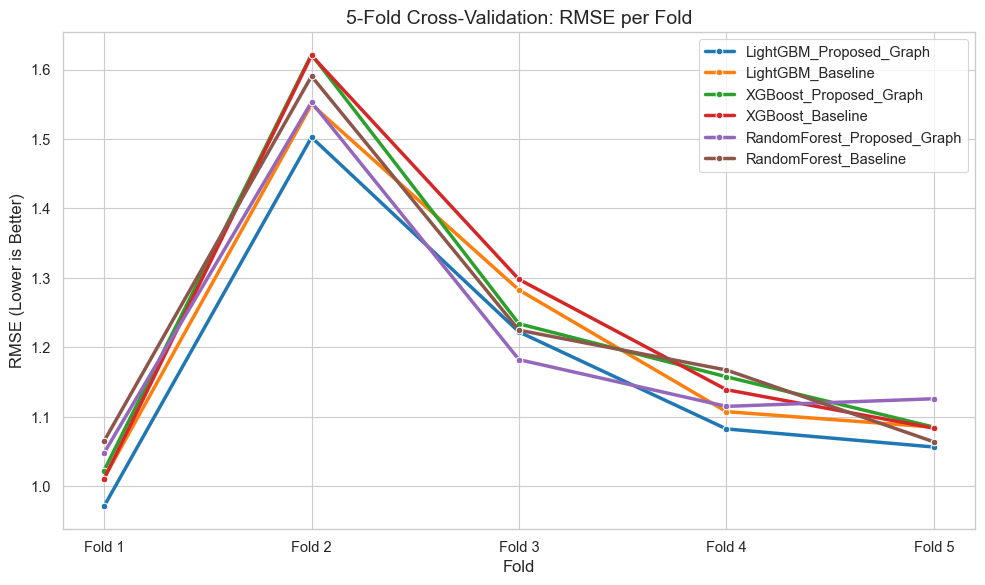

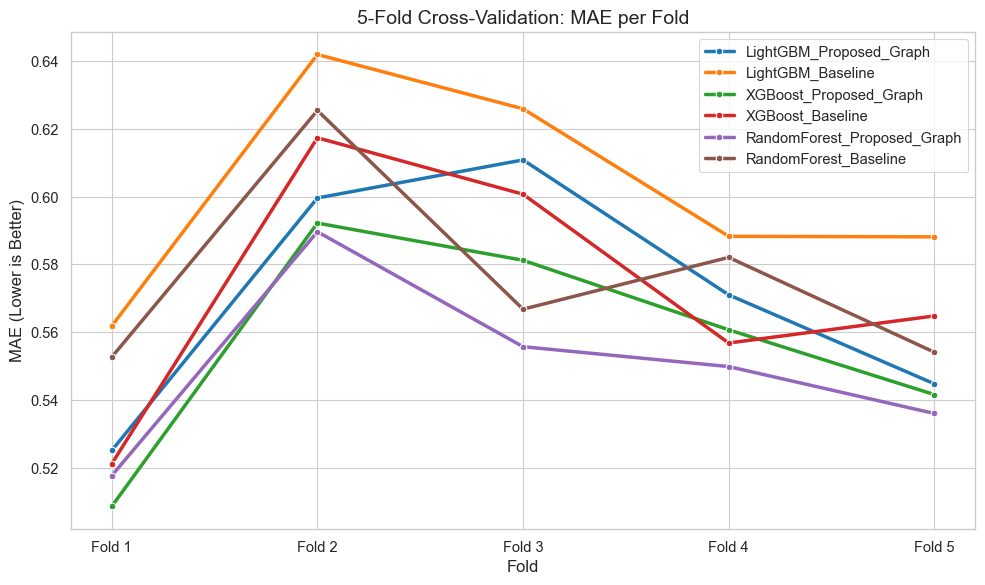

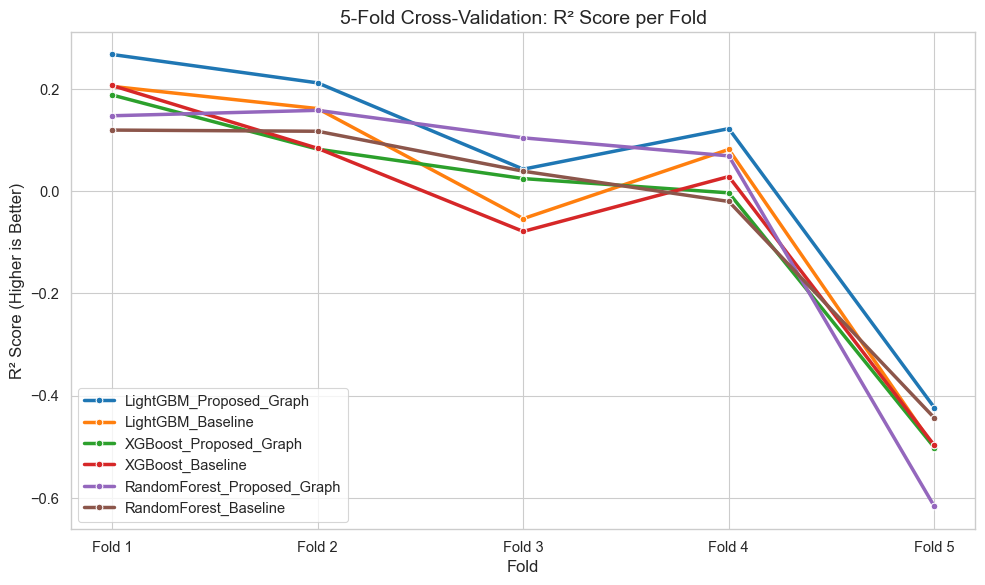


PAIR 2 PRINTOUT: 5-Fold Aggregation (Mean & Std) and Statistical Tests
                      Model  RMSE Mean  RMSE Std  MAE Mean  MAE Std   R2 Mean   R2 Std
    LightGBM_Proposed_Graph   1.166983  0.186156  0.570282 0.032271  0.044827 0.246434
          LightGBM_Baseline   1.207371  0.192924  0.601270 0.028866 -0.020947 0.256134
     XGBoost_Proposed_Graph   1.224168  0.210945  0.556864 0.029754 -0.041519 0.239334
           XGBoost_Baseline   1.230300  0.216647  0.572188 0.033933 -0.050991 0.241610
RandomForest_Proposed_Graph   1.204836  0.179220  0.549773 0.023875 -0.027052 0.296724
      RandomForest_Baseline   1.222276  0.194069  0.576232 0.026818 -0.037143 0.209927

--- STATISTICAL SIGNIFICANCE TEST (Paired T-Test) ---
LightGBM     Baseline vs Proposed | P-Value: 0.003293 | SIGNIFICANT (p<0.05)
XGBoost      Baseline vs Proposed | P-Value: 0.700051 | NOT SIGNIFICANT
RandomForest Baseline vs Proposed | P-Value: 0.446622 | NOT SIGNIFICANT

--- CRITICAL DIFFERENCE (CD) & AVERAGE RAN

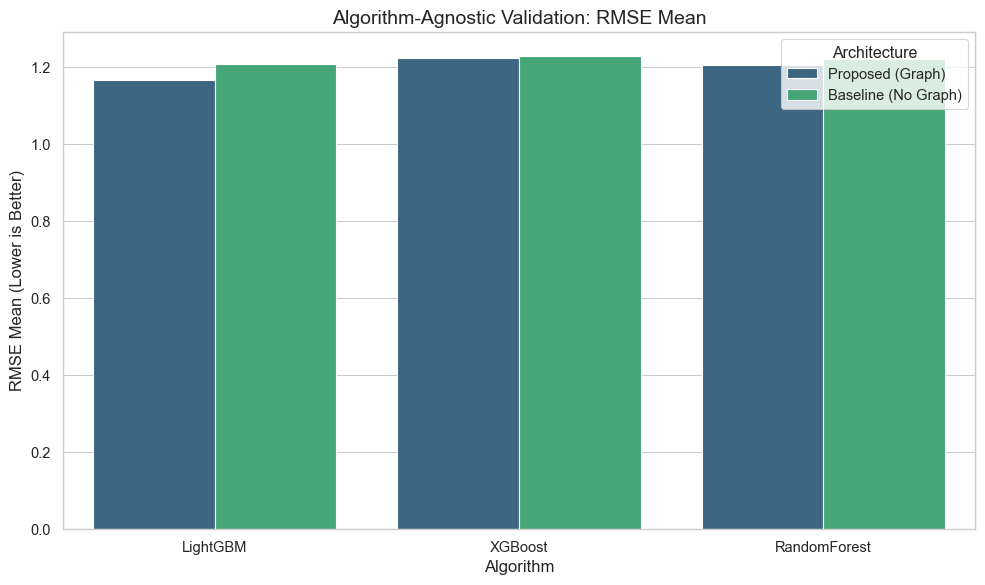

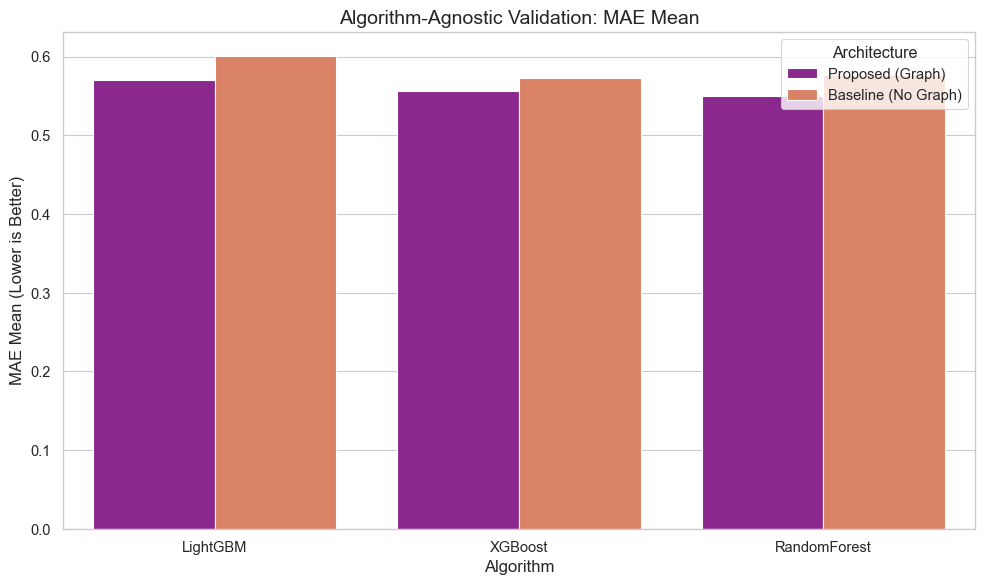

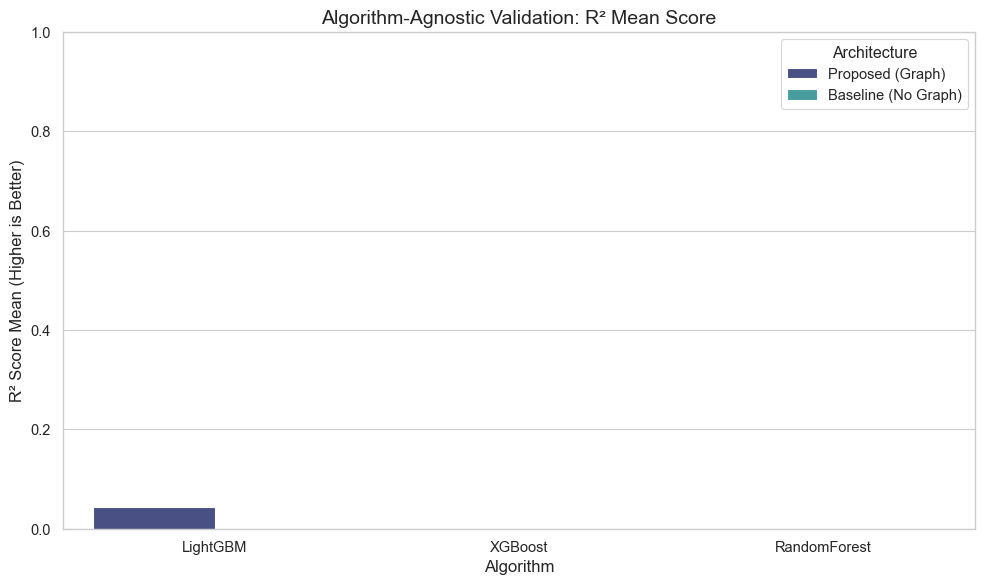

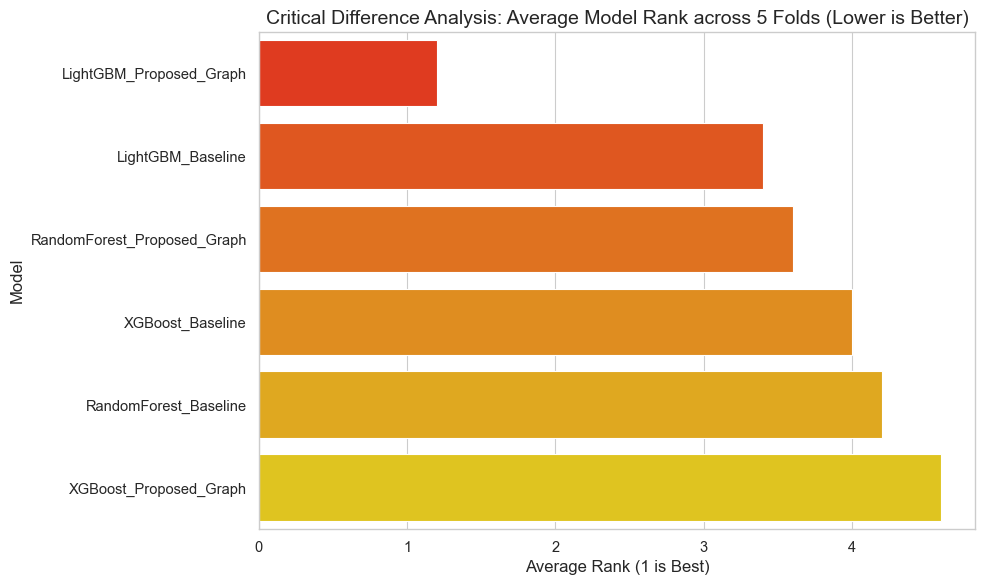

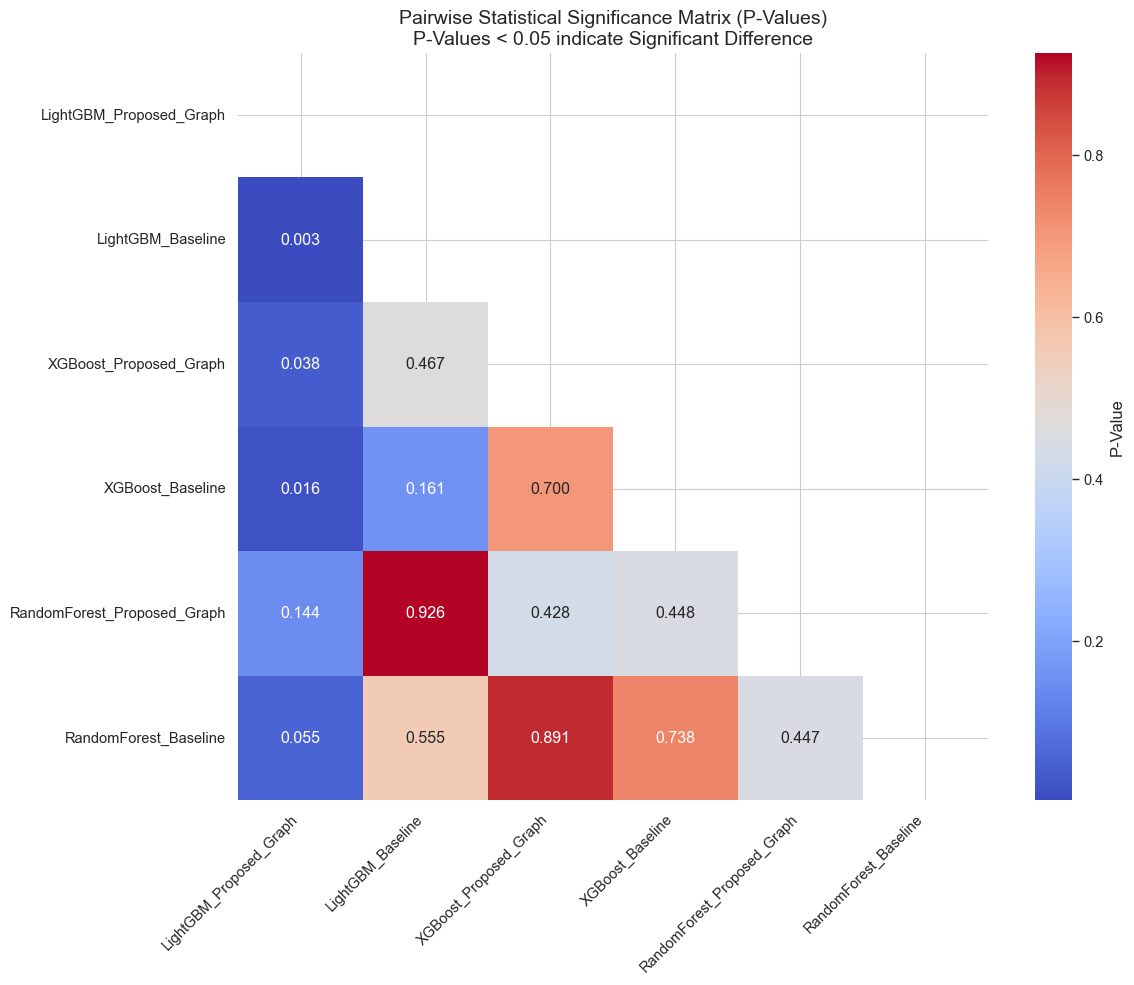

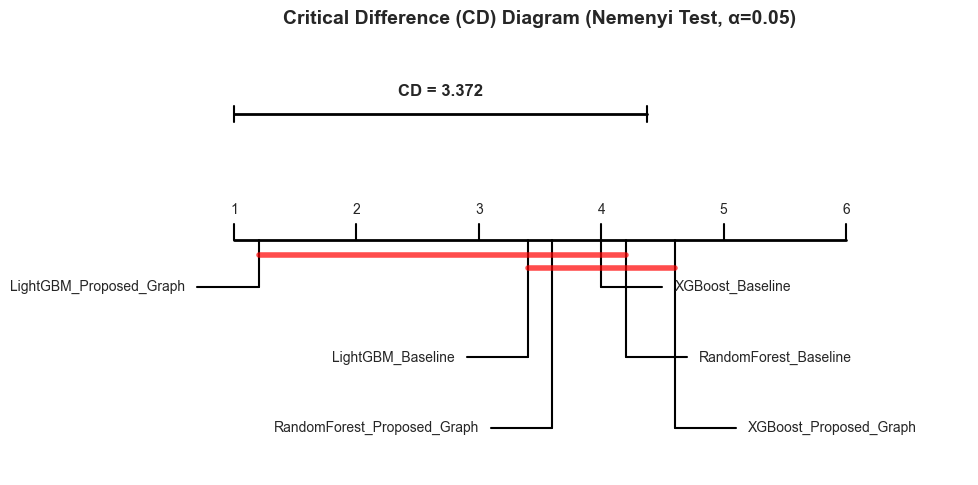


PAIR 3 PRINTOUT: 5-Fold Distribution Quartiles (Violin Plot Counterpart)
--- RMSE Distribution ---
                                  count      mean       std       min       25%       50%       75%       max
Algorithm    Architecture                                                                                    
LightGBM     Baseline (No Graph)    5.0  1.207371  0.215696  1.011778  1.085178  1.107441  1.282656  1.549800
             Proposed (Graph)       5.0  1.166983  0.208129  0.971164  1.056507  1.082570  1.222215  1.502460
RandomForest Baseline (No Graph)    5.0  1.222276  0.216976  1.063981  1.064940  1.167359  1.224745  1.590353
             Proposed (Graph)       5.0  1.204836  0.200374  1.047837  1.115051  1.126028  1.182330  1.552933
XGBoost      Baseline (No Graph)    5.0  1.230300  0.242219  1.010684  1.083653  1.139070  1.297848  1.620246
             Proposed (Graph)       5.0  1.224168  0.235844  1.022491  1.085153  1.157644  1.233928  1.621622

--- MAE Distributio

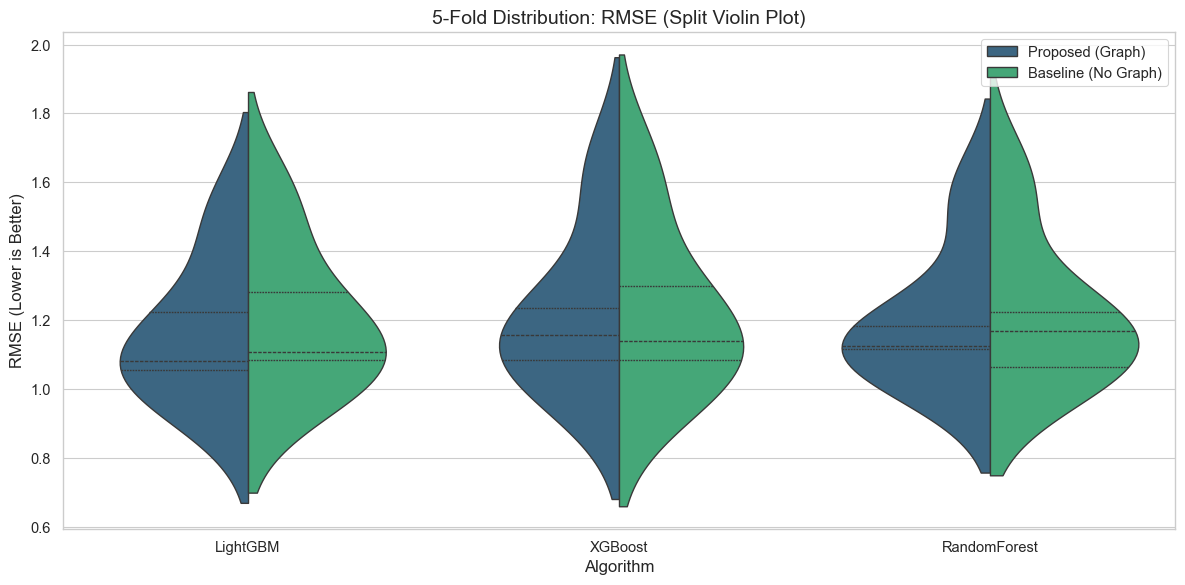

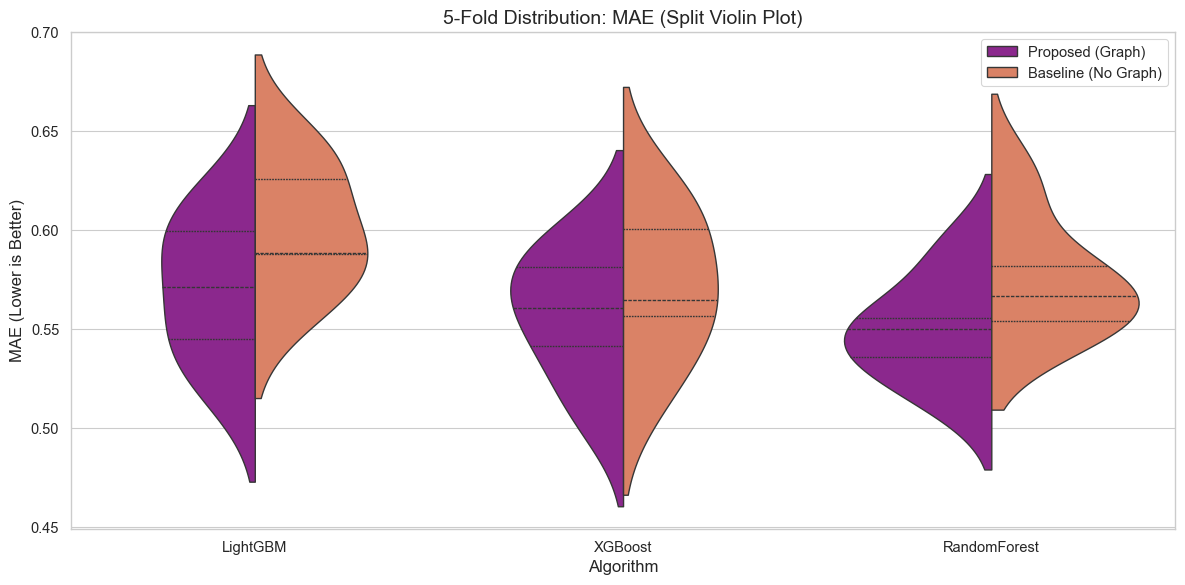

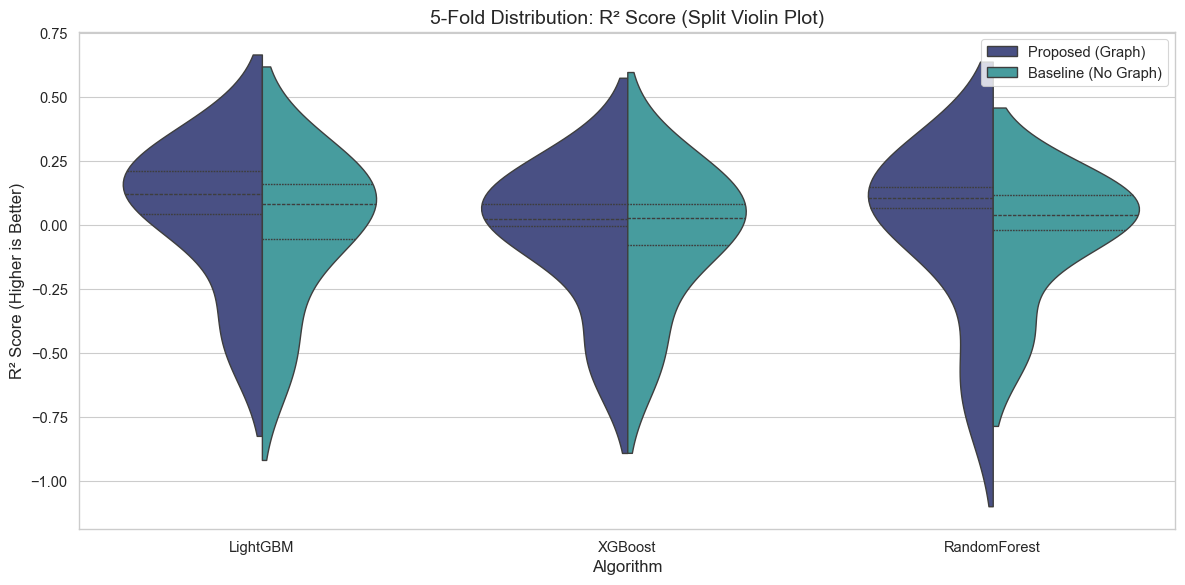


PAIR 4 PRINTOUT: Model Verification - Actual vs Predicted Fluctuation
Rendering Random Sample of N=100 properties. Ground truth ordered by natural index to show demand fluctuations.


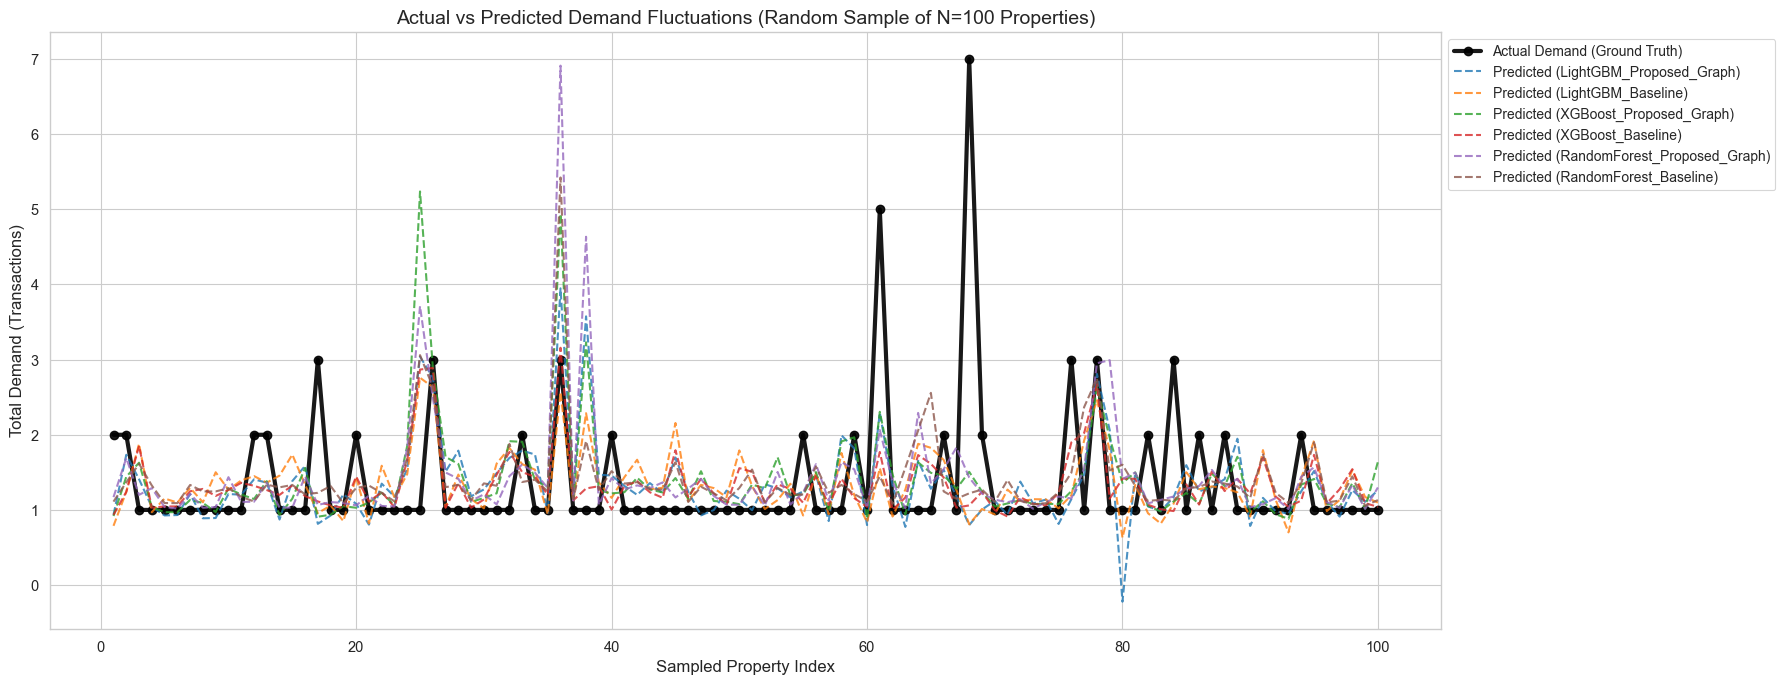


PAIR 5 PRINTOUT: Explainable AI - SHAP, Gain, Split
--- SHAP Global Feature Importance (OOF) ---
           Feature  SHAP Value
          pagerank    0.223034
availability_score    0.133857
  popularity_score    0.115769
       star_rating    0.102706
      price_in_aud    0.087866
  provider_encoded    0.071962
      guest_rating    0.046391
 degree_centrality    0.000000

--- LightGBM Feature Importance (Information Gain) ---
           Feature  Information Gain
availability_score       8059.169682
          pagerank       5786.519760
      price_in_aud       3860.339364
  popularity_score       3853.882567
       star_rating       1705.976378
      guest_rating       1550.496482
  provider_encoded       1509.595026
 degree_centrality          0.000000

--- LightGBM Feature Importance (Split Count) ---
           Feature  Split Count
          pagerank         2707
      price_in_aud         2433
availability_score         2389
  popularity_score         1999
      guest_rating     

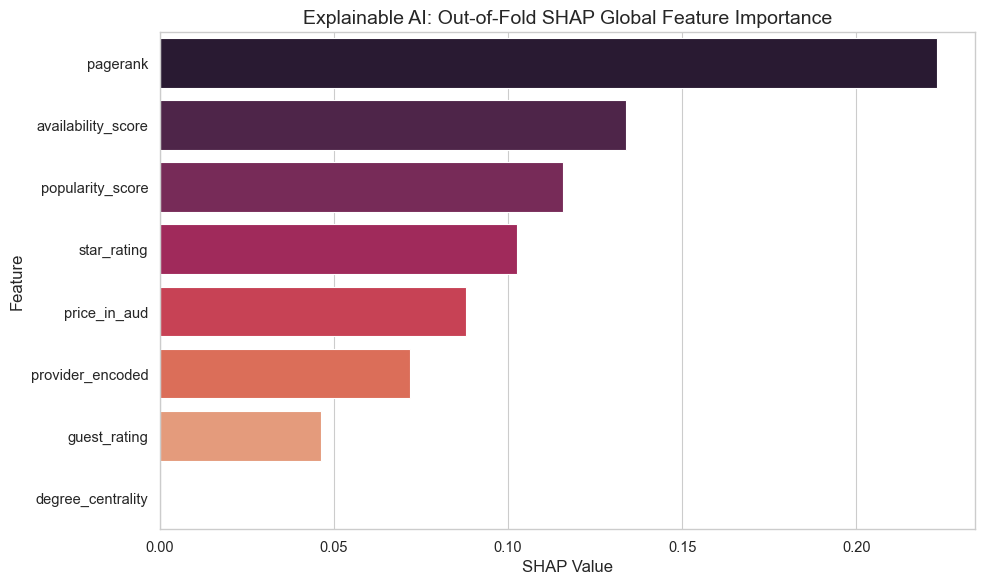

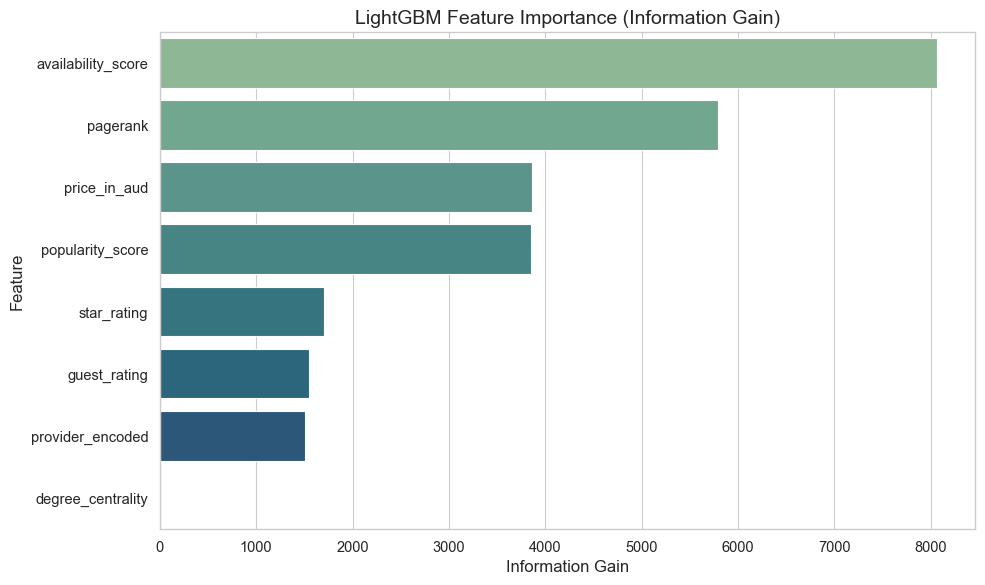

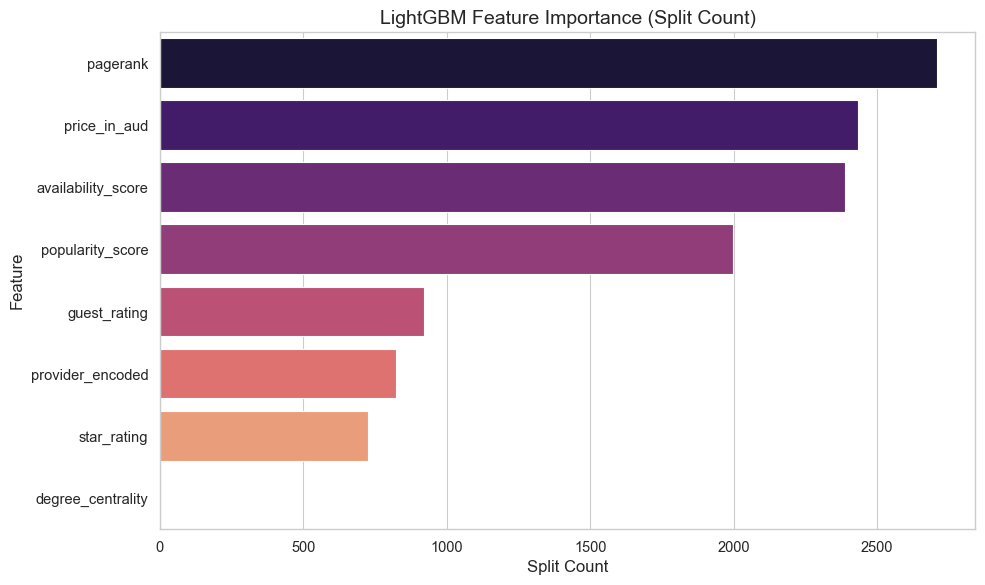


PAIR 6 PRINTOUT: Computational Profiling & Dataset Characteristics
--- Time Complexity Analysis ---
                         Process Phase  Time (Seconds)
               Total Pipeline (5-Fold)       98.578179
                   PageRank Extraction        0.140404
                     Degree Centrality        0.006742
    Train LightGBM_Proposed_Graph (5x)        0.000000
          Train LightGBM_Baseline (5x)        0.000000
     Train XGBoost_Proposed_Graph (5x)        0.000000
           Train XGBoost_Baseline (5x)        0.000000
Train RandomForest_Proposed_Graph (5x)        0.000000
      Train RandomForest_Baseline (5x)        0.000000

--- Spatio-Temporal Graph Characteristics ---
              Metric   Count
    Raw Transactions    3734
   Unique Properties    2799
Total Accommodations 3694025
    Total Activities  522948
         Graph Nodes    8979
         Graph Edges   43650


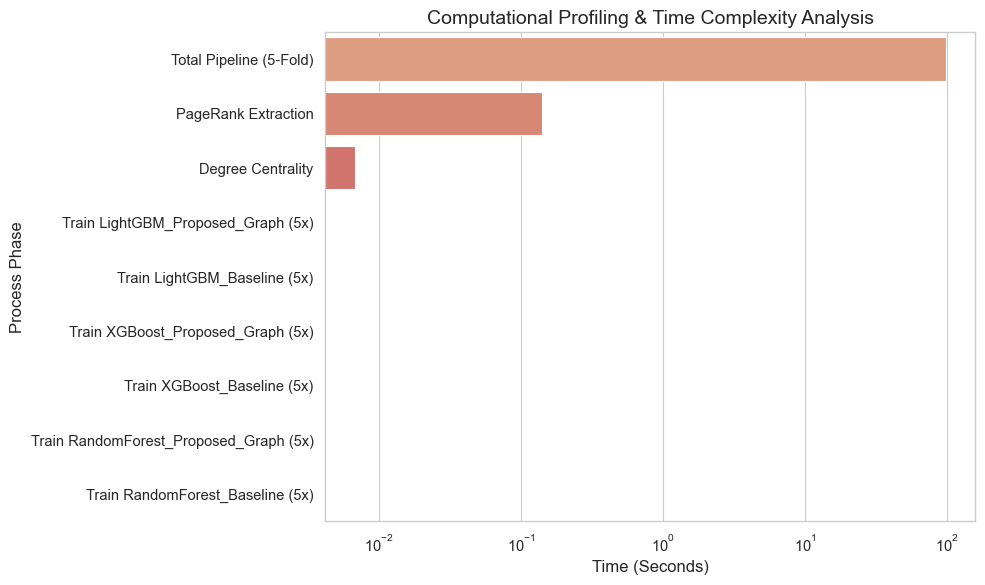

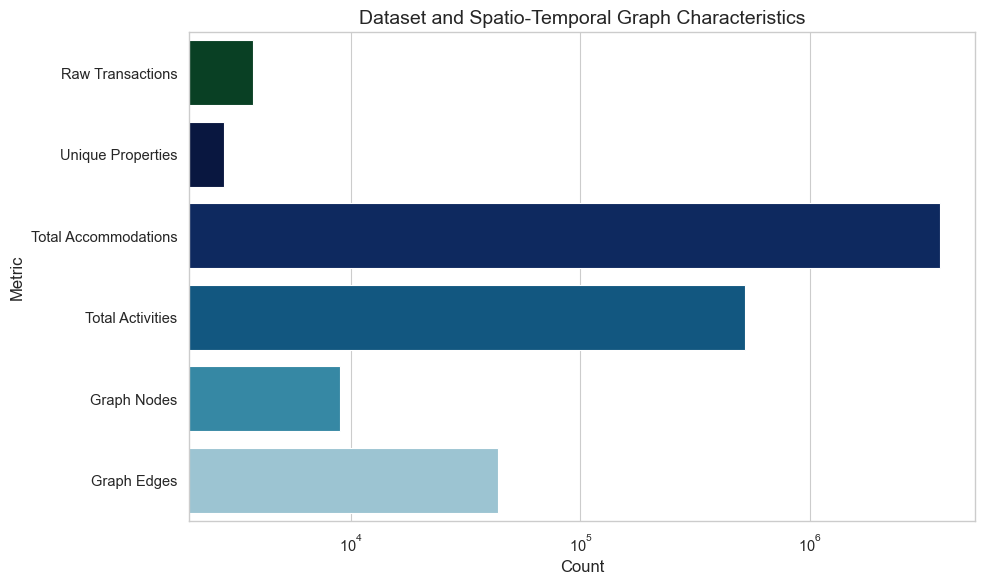


PAIR 7 PRINTOUT: Spatio-Temporal Macro-Topology Flow Matrix
                                  General  Tour And Sight Seeing  Cruises & Sailing  Outdoor Activities  Transport
Expedia|HotelBeds|Agoda|RateHawk     7096                   3690               1215                 416        197
Expedia|RateHawk                     3431                   1894                560                 220        121
Expedia|HotelBeds|RateHawk           3268                   1765                581                 188        113
HotelBeds                            1249                   2084                333                 233        248
Expedia|Agoda|RateHawk               1523                   1033                278                 137         84


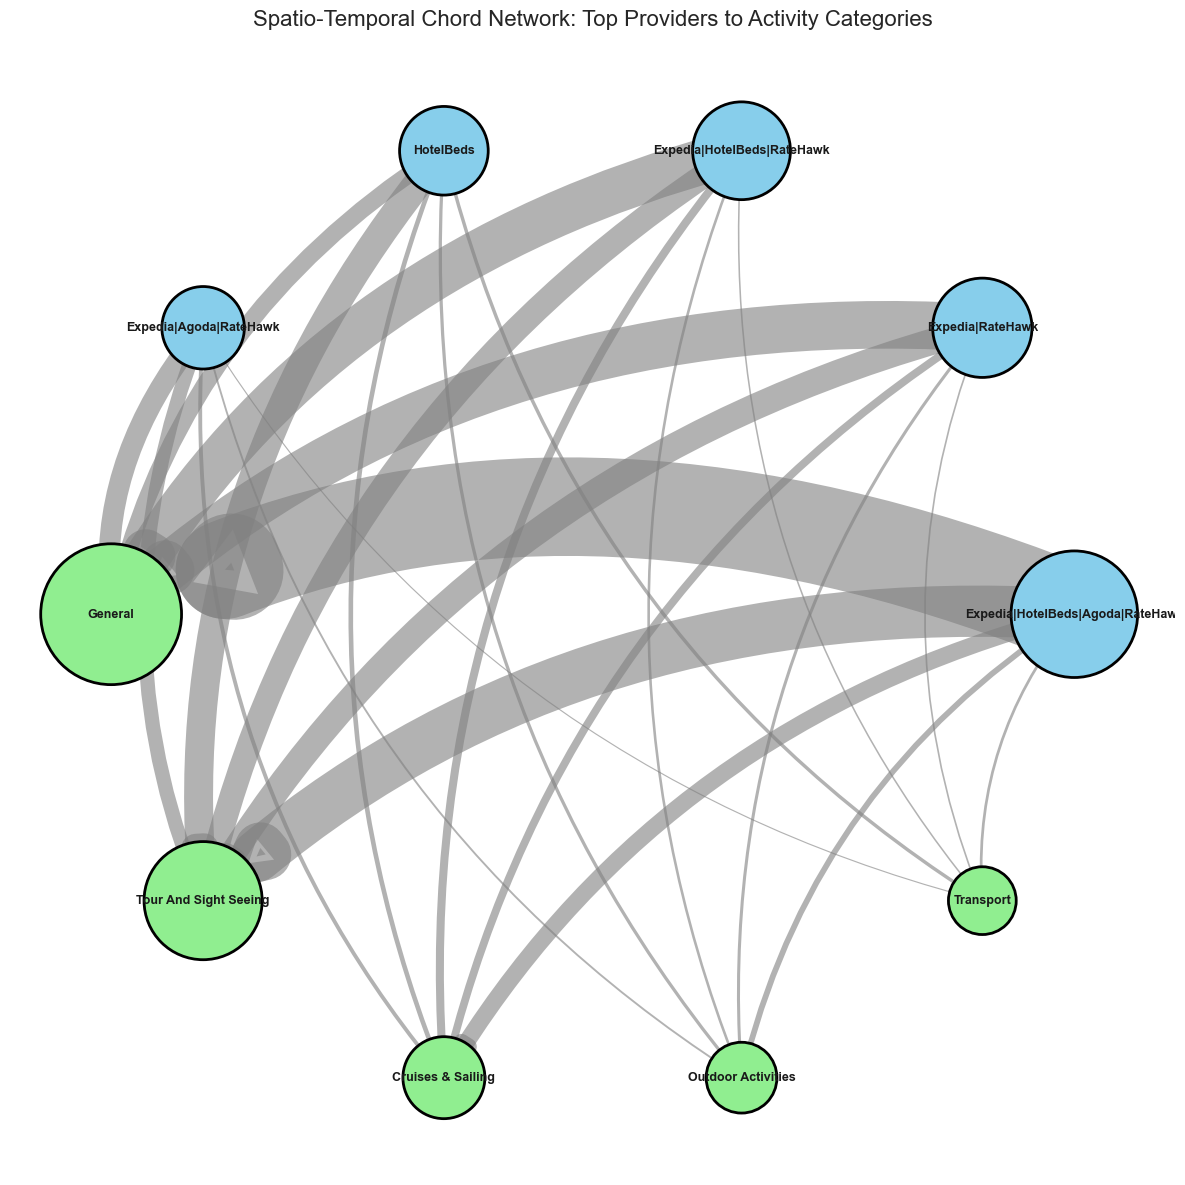

In [20]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import networkx as nx
from scipy import stats
import warnings

def draw_cd_diagram(ranks, names, cd):
    import matplotlib.pyplot as plt
    import numpy as np
    
    k = len(ranks)
    sorted_idx = np.argsort(ranks)
    sorted_ranks = np.array(ranks)[sorted_idx]
    sorted_names = np.array(names)[sorted_idx]
    
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Draw horizontal axis from 1 to k
    ax.plot([1, k], [0, 0], color='black', lw=2)
    for i in range(1, k+1):
        ax.plot([i, i], [0, 0.1], color='black', lw=1.5)
        ax.text(i, 0.15, str(i), ha='center', va='bottom', fontsize=10)
        
    # Draw CD bar at top left
    ax.plot([1, 1 + cd], [0.8, 0.8], color='black', lw=2)
    ax.plot([1, 1], [0.75, 0.85], color='black', lw=1.5)
    ax.plot([1 + cd, 1 + cd], [0.75, 0.85], color='black', lw=1.5)
    ax.text(1 + cd/2, 0.9, f"CD = {cd:.3f}", ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    # Split into left and right groups for text labels
    mid = k // 2
    left_ranks = sorted_ranks[:mid]
    left_names = sorted_names[:mid]
    right_ranks = sorted_ranks[mid:]
    right_names = sorted_names[mid:]
    
    # Determine y-offsets for lines dropping down
    y_drops_left = np.linspace(-0.3, -1.2, len(left_ranks))
    y_drops_right = np.linspace(-0.3, -1.2, len(right_ranks))
    
    for rank, name, y in zip(left_ranks, left_names, y_drops_left):
        ax.plot([rank, rank], [0, y], color='black', lw=1.5)
        ax.plot([rank, rank - 0.5], [y, y], color='black', lw=1.5)
        ax.text(rank - 0.6, y, name, ha='right', va='center', fontsize=10)
        
    for rank, name, y in zip(right_ranks, right_names, y_drops_right):
        ax.plot([rank, rank], [0, y], color='black', lw=1.5)
        ax.plot([rank, rank + 0.5], [y, y], color='black', lw=1.5)
        ax.text(rank + 0.6, y, name, ha='left', va='center', fontsize=10)
        
    # Calculate cliques (groups not significantly different)
    cliques = []
    for i in range(k):
        for j in range(k-1, i, -1):
            if sorted_ranks[j] - sorted_ranks[i] <= cd:
                cliques.append((i, j))
                break
                
    maximal_cliques = []
    for c in cliques:
        is_maximal = True
        for other in cliques:
            if c != other and other[0] <= c[0] and other[1] >= c[1]:
                is_maximal = False
                break
        if is_maximal and c not in maximal_cliques:
            maximal_cliques.append(c)
            
    # Draw thick horizontal lines for cliques
    clique_y = -0.1
    for c in maximal_cliques:
        if c[0] != c[1]: # Only draw if clique has >1 element
            ax.plot([sorted_ranks[c[0]], sorted_ranks[c[1]]], [clique_y, clique_y], color='red', lw=4, alpha=0.7)
            clique_y -= 0.08
            
    ax.set_ylim(-1.5, 1.2)
    ax.set_xlim(0, k+1)
    ax.axis('off')
    plt.title('Critical Difference (CD) Diagram (Nemenyi Test, α=0.05)', pad=20, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

with open('comprehensive_methodology_results.json', 'r') as f:
    results = json.load(f)

eval_data = results['model_evaluation']

# --- DATA PREPARATION ---
fold_details_list = []
model_keys_to_skip = ['y_oof_true_global']
for key, metrics in eval_data.items():
    if key in model_keys_to_skip:
        continue
    algo = key.split('_')[0]
    is_graph = 'Proposed (Graph)' if 'Proposed' in key else 'Baseline (No Graph)'
    for fold_idx in range(5):
        fold_details_list.append({
            'Model': key,
            'Algorithm': algo,
            'Architecture': is_graph,
            'Fold': f'Fold {fold_idx+1}',
            'RMSE': metrics['rmse_folds'][fold_idx],
            'MAE': metrics['mae_folds'][fold_idx],
            'R2': metrics['r2_score_folds'][fold_idx]
        })
fold_df = pd.DataFrame(fold_details_list)

summary_list = []
for key, metrics in eval_data.items():
    if key in model_keys_to_skip:
        continue
    summary_list.append({
        'Model': key,
        'RMSE Mean': metrics['rmse_mean'],
        'RMSE Std': metrics['rmse_std'],
        'MAE Mean': metrics['mae_mean'],
        'MAE Std': metrics['mae_std'],
        'R2 Mean': metrics['r2_score_mean'],
        'R2 Std': metrics['r2_score_std']
    })
summary_df = pd.DataFrame(summary_list)

# =====================================================================
# PAIR 1: DETAILED FOLD FLUCTUATIONS (LINEPLOTS)
# =====================================================================
print("\n" + "="*70)
print("PAIR 1 PRINTOUT: Detailed 5-Fold Fluctuations")
print("="*70)
print(fold_df.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.lineplot(data=fold_df, x='Fold', y='RMSE', hue='Model', marker='o', linewidth=2.5, palette='tab10')
plt.title('5-Fold Cross-Validation: RMSE per Fold')
plt.ylabel('RMSE (Lower is Better)')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.lineplot(data=fold_df, x='Fold', y='MAE', hue='Model', marker='o', linewidth=2.5, palette='tab10')
plt.title('5-Fold Cross-Validation: MAE per Fold')
plt.ylabel('MAE (Lower is Better)')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.lineplot(data=fold_df, x='Fold', y='R2', hue='Model', marker='o', linewidth=2.5, palette='tab10')
plt.title('5-Fold Cross-Validation: R² Score per Fold')
plt.ylabel('R² Score (Higher is Better)')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# =====================================================================
# PAIR 2: AGGREGATED METRICS & STATISTICAL TESTS (BARPLOTS & HEATMAP)
# =====================================================================
print("\n" + "="*70)
print("PAIR 2 PRINTOUT: 5-Fold Aggregation (Mean & Std) and Statistical Tests")
print("="*70)
print(summary_df.to_string(index=False))

print("\n--- STATISTICAL SIGNIFICANCE TEST (Paired T-Test) ---")
algos = ['LightGBM', 'XGBoost', 'RandomForest']
for alg in algos:
    prop_rmse = eval_data[f'{alg}_Proposed_Graph']['rmse_folds']
    base_rmse = eval_data[f'{alg}_Baseline']['rmse_folds']
    t_stat, p_value = stats.ttest_rel(base_rmse, prop_rmse)
    sig = "SIGNIFICANT (p<0.05)" if p_value < 0.05 else "NOT SIGNIFICANT"
    print(f"{alg:12} Baseline vs Proposed | P-Value: {p_value:.6f} | {sig}")

print("\n--- CRITICAL DIFFERENCE (CD) & AVERAGE RANKING ---")
rmse_matrix = np.zeros((5, 6))
model_names = [
    'LightGBM_Proposed_Graph', 'LightGBM_Baseline',
    'XGBoost_Proposed_Graph', 'XGBoost_Baseline',
    'RandomForest_Proposed_Graph', 'RandomForest_Baseline'
]
for j, m in enumerate(model_names):
    rmse_matrix[:, j] = eval_data[m]['rmse_folds']

ranks_matrix = np.zeros((5, 6))
for i in range(5):
    ranks_matrix[i, :] = stats.rankdata(rmse_matrix[i, :])

average_ranks = ranks_matrix.mean(axis=0)
rank_df = pd.DataFrame({'Model': model_names, 'Average Rank': average_ranks})
rank_df = rank_df.sort_values(by='Average Rank')
print(rank_df.to_string(index=False))

p_value_matrix = np.zeros((6, 6))
for i in range(6):
    for j in range(6):
        if i == j:
            p_value_matrix[i, j] = 1.0
        else:
            _, p_val = stats.ttest_rel(rmse_matrix[:, i], rmse_matrix[:, j])
            p_value_matrix[i, j] = p_val

p_val_df = pd.DataFrame(p_value_matrix, index=model_names, columns=model_names)

metrics_list = []
for key, metrics in eval_data.items():
    if key in model_keys_to_skip: continue
    algo = key.split('_')[0]
    is_graph = 'Proposed (Graph)' if 'Proposed' in key else 'Baseline (No Graph)'
    metrics_list.append({'Algorithm': algo, 'Architecture': is_graph, 'Metric': 'RMSE', 'Value': metrics['rmse_mean']})
    metrics_list.append({'Algorithm': algo, 'Architecture': is_graph, 'Metric': 'MAE', 'Value': metrics['mae_mean']})
metrics_df = pd.DataFrame(metrics_list)

r2_list = []
for key, metrics in eval_data.items():
    if key in model_keys_to_skip: continue
    algo = key.split('_')[0]
    is_graph = 'Proposed (Graph)' if 'Proposed' in key else 'Baseline (No Graph)'
    r2_list.append({'Algorithm': algo, 'Architecture': is_graph, 'R-Squared Score': metrics['r2_score_mean']})
r2_df = pd.DataFrame(r2_list)

plt.figure(figsize=(10, 6))
sns.barplot(x='Algorithm', y='Value', hue='Architecture', data=metrics_df[metrics_df['Metric'] == 'RMSE'], palette='viridis')
plt.title('Algorithm-Agnostic Validation: RMSE Mean')
plt.ylabel('RMSE Mean (Lower is Better)')
plt.legend(title='Architecture', loc='best')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x='Algorithm', y='Value', hue='Architecture', data=metrics_df[metrics_df['Metric'] == 'MAE'], palette='plasma')
plt.title('Algorithm-Agnostic Validation: MAE Mean')
plt.ylabel('MAE Mean (Lower is Better)')
plt.legend(title='Architecture', loc='best')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x='Algorithm', y='R-Squared Score', hue='Architecture', data=r2_df, palette='mako')
plt.title('Algorithm-Agnostic Validation: R² Mean Score')
plt.ylabel('R² Score Mean (Higher is Better)')
if r2_df['R-Squared Score'].max() > 0:
    plt.ylim(0, max(r2_df['R-Squared Score'].max() * 1.2, 1.0))
plt.legend(title='Architecture', loc='best')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x='Average Rank', y='Model', data=rank_df, palette='autumn')
plt.title('Critical Difference Analysis: Average Model Rank across 5 Folds (Lower is Better)')
plt.xlabel('Average Rank (1 is Best)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(p_value_matrix, dtype=bool))
sns.heatmap(p_val_df, annot=True, fmt=".3f", cmap='coolwarm', mask=mask, cbar_kws={'label': 'P-Value'})
plt.title('Pairwise Statistical Significance Matrix (P-Values)\nP-Values < 0.05 indicate Significant Difference')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Draw the Demšar style Nemenyi CD diagram
draw_cd_diagram(average_ranks, model_names, 3.372)


# =====================================================================
# PAIR 3: 5-FOLD DISTRIBUTIONS (SPLIT VIOLIN PLOTS)
# =====================================================================
print("\n" + "="*70)
print("PAIR 3 PRINTOUT: 5-Fold Distribution Quartiles (Violin Plot Counterpart)")
print("="*70)
print("--- RMSE Distribution ---")
print(fold_df.groupby(['Algorithm', 'Architecture'])['RMSE'].describe().to_string())
print("\n--- MAE Distribution ---")
print(fold_df.groupby(['Algorithm', 'Architecture'])['MAE'].describe().to_string())
print("\n--- R2 Score Distribution ---")
print(fold_df.groupby(['Algorithm', 'Architecture'])['R2'].describe().to_string())

plt.figure(figsize=(12, 6))
sns.violinplot(data=fold_df, x='Algorithm', y='RMSE', hue='Architecture', split=True, inner='quart', palette='viridis')
plt.title('5-Fold Distribution: RMSE (Split Violin Plot)')
plt.ylabel('RMSE (Lower is Better)')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.violinplot(data=fold_df, x='Algorithm', y='MAE', hue='Architecture', split=True, inner='quart', palette='plasma')
plt.title('5-Fold Distribution: MAE (Split Violin Plot)')
plt.ylabel('MAE (Lower is Better)')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.violinplot(data=fold_df, x='Algorithm', y='R2', hue='Architecture', split=True, inner='quart', palette='mako')
plt.title('5-Fold Distribution: R² Score (Split Violin Plot)')
plt.ylabel('R² Score (Higher is Better)')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# =====================================================================
# PAIR 4: ACTUAL VS PREDICTED FLUCTUATIONS
# =====================================================================
y_true_full = np.array(eval_data['y_oof_true_global'])
sample_df = pd.DataFrame({'Actual Demand': y_true_full})
model_keys = ['LightGBM_Proposed_Graph', 'LightGBM_Baseline', 'XGBoost_Proposed_Graph', 'XGBoost_Baseline', 'RandomForest_Proposed_Graph', 'RandomForest_Baseline']

for m_key in model_keys:
    sample_df[m_key] = np.array(eval_data[m_key]['y_oof_pred'])

sampled_data = sample_df.sample(n=100, random_state=42).sort_index().reset_index(drop=True)
indices = np.arange(1, len(sampled_data) + 1)

print("\n" + "="*70)
print("PAIR 4 PRINTOUT: Model Verification - Actual vs Predicted Fluctuation")
print("="*70)
print("Rendering Random Sample of N=100 properties. Ground truth ordered by natural index to show demand fluctuations.")

plt.figure(figsize=(18, 7))
plt.plot(indices, sampled_data['Actual Demand'], label='Actual Demand (Ground Truth)', color='black', linewidth=3.0, marker='o', markersize=6, alpha=0.9)
colors = sns.color_palette('tab10', 6)
for idx, model_key in enumerate(model_keys):
    plt.plot(indices, sampled_data[model_key], label=f'Predicted ({model_key})', color=colors[idx], linewidth=1.5, alpha=0.8, linestyle='--')
plt.title('Actual vs Predicted Demand Fluctuations (Random Sample of N=100 Properties)')
plt.ylabel('Total Demand (Transactions)')
plt.xlabel('Sampled Property Index')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)
plt.tight_layout()
plt.show()

# =====================================================================
# PAIR 5: EXPLAINABLE AI (SHAP & GAIN)
# =====================================================================
shap_vals = results['interpretability']['shap_mean_absolute_values_oof']
shap_df = pd.DataFrame(list(shap_vals.items()), columns=['Feature', 'SHAP Value']).sort_values(by='SHAP Value', ascending=False)

gain_vals = results['interpretability']['lightgbm_gain_importance_full']
gain_df = pd.DataFrame(list(gain_vals.items()), columns=['Feature', 'Information Gain']).sort_values(by='Information Gain', ascending=False)

split_vals = results['interpretability']['lightgbm_split_importance_full']
split_df = pd.DataFrame(list(split_vals.items()), columns=['Feature', 'Split Count']).sort_values(by='Split Count', ascending=False)

print("\n" + "="*70)
print("PAIR 5 PRINTOUT: Explainable AI - SHAP, Gain, Split")
print("="*70)
print("--- SHAP Global Feature Importance (OOF) ---")
print(shap_df.to_string(index=False))
print("\n--- LightGBM Feature Importance (Information Gain) ---")
print(gain_df.to_string(index=False))
print("\n--- LightGBM Feature Importance (Split Count) ---")
print(split_df.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(x='SHAP Value', y='Feature', data=shap_df, palette='rocket')
plt.title('Explainable AI: Out-of-Fold SHAP Global Feature Importance')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x='Information Gain', y='Feature', data=gain_df, palette='crest')
plt.title('LightGBM Feature Importance (Information Gain)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x='Split Count', y='Feature', data=split_df, palette='magma')
plt.title('LightGBM Feature Importance (Split Count)')
plt.tight_layout()
plt.show()

# =====================================================================
# PAIR 6: COMPUTATIONAL PROFILING & DATASET TOPOLOGY
# =====================================================================
comp_eff = results['computational_efficiency']
time_list = [
    {'Process Phase': 'PageRank Extraction', 'Time (Seconds)': comp_eff['pagerank_seconds']},
    {'Process Phase': 'Degree Centrality', 'Time (Seconds)': comp_eff['degree_centrality_seconds']},
    {'Process Phase': 'Total Pipeline (5-Fold)', 'Time (Seconds)': comp_eff['total_pipeline_seconds']}
]
for key, metrics in eval_data.items():
    if key in model_keys_to_skip: continue
    time_list.append({'Process Phase': f'Train {key} (5x)', 'Time (Seconds)': np.sum(metrics['training_time_seconds_folds'])})

comp_df = pd.DataFrame(time_list).sort_values(by='Time (Seconds)', ascending=False)

stats_data = results['dataset_statistics']
graph_top = results['graph_topology']
topology_df = pd.DataFrame({
    'Metric': ['Raw Transactions', 'Unique Properties', 'Total Accommodations', 'Total Activities', 'Graph Nodes', 'Graph Edges'],
    'Count': [stats_data['raw_transactions_records'], stats_data['unique_properties_in_transactions'], stats_data['total_accommodations_loaded'], stats_data['total_activities_loaded'], graph_top['total_nodes'], graph_top['total_edges']]
})

print("\n" + "="*70)
print("PAIR 6 PRINTOUT: Computational Profiling & Dataset Characteristics")
print("="*70)
print("--- Time Complexity Analysis ---")
print(comp_df.to_string(index=False))
print("\n--- Spatio-Temporal Graph Characteristics ---")
print(topology_df.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(x='Time (Seconds)', y='Process Phase', data=comp_df, palette='flare')
plt.title('Computational Profiling & Time Complexity Analysis')
plt.xscale('log')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x='Count', y='Metric', data=topology_df, palette='ocean')
plt.title('Dataset and Spatio-Temporal Graph Characteristics')
plt.xscale('log')
plt.tight_layout()
plt.show()

# =====================================================================
# PAIR 7: SPATIO-TEMPORAL MACRO-TOPOLOGY CHORD NETWORK
# =====================================================================
flow_matrix = results['graph_topology'].get('macro_flow_matrix', {})
if flow_matrix:
    print("\n" + "="*70)
    print("PAIR 7 PRINTOUT: Spatio-Temporal Macro-Topology Flow Matrix")
    print("="*70)
    flow_df_print = pd.DataFrame(flow_matrix).fillna(0).T
    print(flow_df_print.to_string())

    plt.figure(figsize=(12, 12))
    G_flow = nx.DiGraph()
    providers = list(flow_matrix.keys())
    categories = []
    for p, cats in flow_matrix.items():
        for c in cats.keys():
            if c not in categories:
                categories.append(c)
    
    for p in providers: G_flow.add_node(p, bipartite=0)
    for c in categories: G_flow.add_node(c, bipartite=1)
    
    for p, cats in flow_matrix.items():
        for c, weight in cats.items():
            if weight > 0:
                G_flow.add_edge(p, c, weight=weight)
    
    pos = nx.circular_layout(G_flow)
    node_colors = ['skyblue' if n in providers else 'lightgreen' for n in G_flow.nodes()]
    node_sizes = []
    for n in G_flow.nodes():
        if n in providers:
            degree_w = sum([G_flow[n][v]['weight'] for v in G_flow.successors(n)])
            node_sizes.append(degree_w * 0.5 + 2000)
        else:
            degree_w = sum([G_flow[u][n]['weight'] for u in G_flow.predecessors(n)])
            node_sizes.append(degree_w * 0.5 + 2000)
            
    edges = G_flow.edges(data=True)
    
    nx.draw_networkx_nodes(G_flow, pos, node_color=node_colors, node_size=node_sizes, edgecolors='black', linewidths=2)
    nx.draw_networkx_labels(G_flow, pos, font_size=9, font_weight='bold')
    
    for (u, v, d) in edges:
        nx.draw_networkx_edges(G_flow, pos, edgelist=[(u,v)], width=d['weight']*0.01, alpha=0.6, edge_color='gray', connectionstyle='arc3,rad=0.2', arrowsize=15)
        
    plt.title('Spatio-Temporal Chord Network: Top Providers to Activity Categories', fontsize=16, pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()